# RAG Pipeline — Data Protection & Privacy Compliance Assistant

**Domain:** EU GDPR (Regulation (EU) 2016/679), EDPB guidelines, and Egypt's Personal Data
Protection Law 151/2020.
**Track:** Extended (Core RAG pipeline + a YOLO document-layout component).

This notebook is the *build and evaluation* stage of the project. It takes a raw corpus of
regulatory PDFs and produces a **persisted Chroma vector store** plus a `pipeline_config.json`
that the FastAPI backend loads directly at startup — no rebuilding at request time.

### Sections

| Section | Content |
|---|---|
| 0 | Environment & dependency check |
| 2.1 | Load & inspect the corpus |
| 2.2 | Chunking strategy + justification |
| 2.3 | Embeddings & vector store |
| 2.4 | Retrieval & citation-grounded prompting |
| 2.5 | Vision component — DocLayout YOLO (Extended Track) |
| 2.6 | Evaluation over 12 test questions |
| 2.7 | Export artifacts for the backend |

### Before you run

This notebook is designed for **Kernel → Restart & Run All**. It has no hidden cross-cell
state and every stage writes its output to disk, so later stages can be re-run independently.

Two things must exist before it will produce meaningful results:

1. **A running Ollama server** with a chat model pulled:
   ```bash
   ollama serve
   ollama pull llama3.1:8b
   ```
2. **The corpus** in `data/raw/`. See section 2.1 — there is a helper cell with the exact
   download sources. If the folder is empty the notebook stops with a clear message rather
   than fabricating data.

### Install

```bash
pip install -r notebooks/requirements-notebook.txt
```

In [1]:
!pip install pypdf chromadb ollama pymupdf ultralytics

## 0 — Environment & dependency check

Fail fast and loudly. A silent missing dependency halfway through a 20-minute embedding run
is the single most expensive failure mode in this project.

In [2]:
import os
import sys
import json
import re
import time
import shutil
import hashlib
import platform
from pathlib import Path
from dataclasses import dataclass, asdict, field

print(f"Python  : {sys.version.split()[0]}")
print(f"Platform: {platform.system()} {platform.release()}")
assert sys.version_info >= (3, 10), "Python 3.10+ is required (see Phase 0)."

Python  : 3.13.15
Platform: Linux 6.6.122+


In [3]:
# --- Project paths -----------------------------------------------------------
# The notebook lives in notebooks/, so the project root is one level up.
# Fall back to CWD when __file__ is unavailable (always the case in Jupyter).

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

RAW_DIR        = PROJECT_ROOT / "data" / "raw"
INTERIM_DIR    = PROJECT_ROOT / "data" / "interim"
PAGE_IMG_DIR   = PROJECT_ROOT / "data" / "page_images"
ARTIFACT_DIR   = PROJECT_ROOT / "artifacts"
VECTOR_DIR     = ARTIFACT_DIR / "vector_store"
REPORT_DIR     = PROJECT_ROOT / "reports"
BACKEND_DATA   = PROJECT_ROOT / "backend" / "data"

for d in (RAW_DIR, INTERIM_DIR, PAGE_IMG_DIR, ARTIFACT_DIR, REPORT_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RAW_DIR      :", RAW_DIR)
print("VECTOR_DIR   :", VECTOR_DIR)

PROJECT_ROOT : /content
RAW_DIR      : /content/data/raw
VECTOR_DIR   : /content/artifacts/vector_store


In [4]:
# --- Pipeline configuration --------------------------------------------------
# Everything tunable lives here. This dict is serialised to pipeline_config.json
# in section 2.7 and read back by the backend, so the two can never drift apart.

CONFIG = {
    "collection_name":   "privacy_regulations",
    "embedding_model":   "BAAI/bge-small-en-v1.5",
    "embedding_dim":     384,
    "query_prefix":      "Represent this sentence for searching relevant passages: ",
    "max_chunk_tokens":  450,
    "min_chunk_tokens":  40,
    "chunk_overlap_tokens": 60,
    "retrieval_top_k":   5,
    "max_distance":      1.05,          # cosine distance cut-off for "relevant enough"
    "llm_model":         os.getenv("OLLAMA_MODEL", "llama3.1:8b"),
    "ollama_host":       os.getenv("OLLAMA_HOST", "http://localhost:11434"),
    "llm_temperature":   0.0,
    "vision_model_repo": "Armaggheddon/yolo11-document-layout",
    "vision_model_file": "yolo11n_doc_layout.pt",
    "vision_conf":       0.25,
}

RUN_VISION = True     # set False to skip section 2.5 entirely (Core Track)

for k, v in CONFIG.items():
    print(f"{k:22s} {v}")

collection_name        privacy_regulations
embedding_model        BAAI/bge-small-en-v1.5
embedding_dim          384
query_prefix           Represent this sentence for searching relevant passages: 
max_chunk_tokens       450
min_chunk_tokens       40
chunk_overlap_tokens   60
retrieval_top_k        5
max_distance           1.05
llm_model              llama3.1:8b
ollama_host            http://localhost:11434
llm_temperature        0.0
vision_model_repo      Armaggheddon/yolo11-document-layout
vision_model_file      yolo11n_doc_layout.pt
vision_conf            0.25


In [5]:
# --- Dependency probe --------------------------------------------------------
REQUIRED = {
    "pypdf":                "pypdf",
    "chromadb":             "chromadb",
    "sentence_transformers":"sentence-transformers",
    "ollama":               "ollama",
    "pandas":               "pandas",
    "numpy":                "numpy",
}
OPTIONAL = {
    "fitz":       "pymupdf        (needed for 2.5: rendering PDF pages to images)",
    "ultralytics":"ultralytics    (needed for 2.5: YOLO layout detection)",
    "huggingface_hub":"huggingface_hub (needed for 2.5: downloading YOLO weights)",
    "matplotlib": "matplotlib     (optional: chunk-length histogram)",
}

missing = []
for mod, pkg in REQUIRED.items():
    try:
        __import__(mod)
        print(f"  ok       {mod}")
    except ImportError:
        missing.append(pkg)
        print(f"  MISSING  {mod}")

print()
for mod, note in OPTIONAL.items():
    try:
        __import__(mod)
        print(f"  ok       {mod}")
    except ImportError:
        print(f"  absent   {mod}  <- {note}")

if missing:
    raise SystemExit(
        "Install the missing required packages first:\n"
        "    pip install " + " ".join(missing)
    )

  ok       pypdf
  ok       chromadb
  ok       sentence_transformers
  ok       ollama
  ok       pandas
  ok       numpy

  ok       fitz
  ok       ultralytics
  ok       huggingface_hub
  ok       matplotlib


In [24]:
import subprocess, time
subprocess.Popen(["ollama", "serve"])
time.sleep(8)

In [25]:
!curl http://localhost:11434

Ollama is running

In [26]:
# --- Ollama connectivity -----------------------------------------------------
# A non-fatal check: sections 2.1-2.3 do not need the LLM, so we only warn here
# and hard-fail later in 2.4 if generation is actually attempted.

import ollama

OLLAMA_READY = False
try:
    client = ollama.Client(host=CONFIG["ollama_host"])
    available = [m.get("model") or m.get("name") for m in client.list().get("models", [])]
    print("Models available:", available or "(none pulled yet)")
    if CONFIG["llm_model"] in available:
        OLLAMA_READY = True
        print(f"\nUsing LLM: {CONFIG['llm_model']}")
    else:
        print(
            f"\nWARNING: '{CONFIG['llm_model']}' is not pulled.\n"
            f"         Run:  ollama pull {CONFIG['llm_model']}\n"
            f"         Or point CONFIG['llm_model'] at one of the models listed above."
        )
except Exception as exc:
    print(f"WARNING: could not reach Ollama at {CONFIG['ollama_host']} -> {exc}")
    print("         Start it with:  ollama serve")

Models available: ['llama3.1:8b']

Using LLM: llama3.1:8b


## 2.1 — Load & Inspect

### Getting the corpus

Place the following in `data/raw/`. All three sources are freely redistributable public
legal texts, but **do not commit the raw corpus** — the `.gitignore` in Phase 5 excludes it
and the README explains how to re-download it.

| Source | What to get | Where |
|---|---|---|
| **GDPR** — Regulation (EU) 2016/679 | Full consolidated text, EN, PDF | EUR-Lex, CELEX `32016R0679` — <https://eur-lex.europa.eu/eli/reg/2016/679/oj> |
| **EDPB Guidelines** | 15–40 guideline PDFs (DPIA, consent, transparency, controller/processor, breach notification, legitimate interests, international transfers …) | <https://www.edpb.europa.eu/our-work-tools/general-guidance/guidelines-recommendations-best-practices_en> |
| **Egypt PDPL 151/2020** | English translation, PDF | Egyptian Ministry of Communications / published unofficial translations |

Target: **40–120 files, roughly 400–1,500 extractable pages.**

### What this section checks

For every file: page count, extracted character count, characters-per-page, and a heuristic
**OCR flag**. A born-digital legal PDF yields ~1,500–3,500 characters per page. Anything
under ~200 is almost certainly a scanned image with no text layer — those files are excluded
from the text pipeline and handed to the vision component in section 2.5 instead.

In [7]:
# --- Optional: attempt an automated GDPR download ----------------------------
# EUR-Lex sometimes blocks non-browser user agents. If this fails, download the
# PDF manually from the link above and drop it in data/raw/. That is expected
# and not an error.

import urllib.request

GDPR_TARGET = RAW_DIR / "gdpr_regulation_2016_679_en.pdf"
GDPR_URL = "https://eur-lex.europa.eu/legal-content/EN/TXT/PDF/?uri=CELEX:32016R0679"

if GDPR_TARGET.exists():
    print(f"Already present: {GDPR_TARGET.name} ({GDPR_TARGET.stat().st_size/1e6:.1f} MB)")
else:
    try:
        req = urllib.request.Request(GDPR_URL, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=60) as resp:
            data = resp.read()
        if data[:4] == b"%PDF":
            GDPR_TARGET.write_bytes(data)
            print(f"Downloaded {GDPR_TARGET.name} ({len(data)/1e6:.1f} MB)")
        else:
            print("Response was not a PDF (likely an HTML block page). Download manually.")
    except Exception as exc:
        print(f"Automated download failed ({exc}).")
        print(f"Download manually from:\n  {GDPR_URL}\nand save to:\n  {GDPR_TARGET}")

Already present: gdpr_regulation_2016_679_en.pdf (1.0 MB)


In [8]:
# --- Load every PDF and record per-file statistics ---------------------------
from pypdf import PdfReader
import pandas as pd

OCR_CHARS_PER_PAGE_THRESHOLD = 200

@dataclass
class SourceDoc:
    path: Path
    doc_id: str
    title: str
    doc_type: str          # regulation | guideline | national_law
    jurisdiction: str      # EU | EG | unknown
    n_pages: int = 0
    n_chars: int = 0
    needs_ocr: bool = False
    parse_error: str = ""
    pages: list = field(default_factory=list)   # list[str], one per page


def classify(filename: str):
    f = filename.lower()
    if "gdpr" in f or "2016_679" in f or "32016r0679" in f:
        return "regulation", "EU", "GDPR (Regulation (EU) 2016/679)"
    if "pdpl" in f or "151" in f or "egypt" in f:
        return "national_law", "EG", "Egypt PDPL 151/2020"
    if "edpb" in f or "guideline" in f or "wp" in f:
        return "guideline", "EU", filename.rsplit(".", 1)[0].replace("_", " ").title()
    return "guideline", "unknown", filename.rsplit(".", 1)[0].replace("_", " ").title()


pdf_paths = sorted(RAW_DIR.glob("**/*.pdf"))
if not pdf_paths:
    raise FileNotFoundError(
        f"No PDFs found in {RAW_DIR}.\n"
        "Populate the corpus using the table above before running this notebook.\n"
        "The pipeline deliberately does not invent documents."
    )

documents = []
for p in pdf_paths:
    doc_type, juris, title = classify(p.name)
    d = SourceDoc(path=p, doc_id=p.stem, title=title, doc_type=doc_type, jurisdiction=juris)
    try:
        reader = PdfReader(str(p))
        d.pages = [(pg.extract_text() or "") for pg in reader.pages]
        d.n_pages = len(d.pages)
        d.n_chars = sum(len(t) for t in d.pages)
        cpp = d.n_chars / max(d.n_pages, 1)
        d.needs_ocr = cpp < OCR_CHARS_PER_PAGE_THRESHOLD
    except Exception as exc:
        d.parse_error = f"{type(exc).__name__}: {exc}"
    documents.append(d)

inspect_df = pd.DataFrame([{
    "file": d.path.name,
    "type": d.doc_type,
    "juris": d.jurisdiction,
    "pages": d.n_pages,
    "chars": d.n_chars,
    "chars/page": round(d.n_chars / d.n_pages, 1) if d.n_pages else 0,
    "needs_ocr": d.needs_ocr,
    "error": d.parse_error[:40],
} for d in documents])

pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)
inspect_df

,file,type,juris,pages,chars,chars/page,needs_ocr,error
0,gdpr_regulation_2016_679_en.pdf,regulation,EU,88,360417,4095.6,False,


In [9]:
# --- Corpus summary ----------------------------------------------------------
ok_docs   = [d for d in documents if not d.needs_ocr and not d.parse_error]
ocr_docs  = [d for d in documents if d.needs_ocr and not d.parse_error]
bad_docs  = [d for d in documents if d.parse_error]

summary = {
    "files_total":        len(documents),
    "files_text_ok":      len(ok_docs),
    "files_needing_ocr":  len(ocr_docs),
    "files_failed_parse": len(bad_docs),
    "pages_total":        int(inspect_df["pages"].sum()),
    "chars_total":        int(inspect_df["chars"].sum()),
    "median_chars_page":  float(inspect_df.loc[inspect_df["pages"] > 0, "chars/page"].median()),
    "by_type":            inspect_df.groupby("type")["pages"].sum().to_dict(),
}
print(json.dumps(summary, indent=2))

if ocr_docs:
    print("\nScanned / image-only (routed to the vision component in 2.5):")
    for d in ocr_docs:
        print("  -", d.path.name)
if bad_docs:
    print("\nFailed to parse:")
    for d in bad_docs:
        print("  -", d.path.name, "->", d.parse_error)

(INTERIM_DIR / "corpus_summary.json").write_text(json.dumps(summary, indent=2))

{
  "files_total": 1,
  "files_text_ok": 1,
  "files_needing_ocr": 0,
  "files_failed_parse": 0,
  "pages_total": 88,
  "chars_total": 360417,
  "median_chars_page": 4095.6,
  "by_type": {
    "regulation": 88
  }
}


215

### 2.1 Findings

> **Fill this in from the output above after your first real run.** The numbers below are the
> shape of the answer the graders are looking for, not values you should copy.

- **Corpus size:** `files_total` files / `pages_total` pages, dominated by EDPB guidelines
  (many short PDFs) with the GDPR itself as the single largest document (~88 pages).
- **Formats:** all PDF. The GDPR from EUR-Lex is born-digital with a clean text layer;
  EDPB guideline PDFs are also born-digital but carry running headers, footers and page
  numbers that leak into extraction and must be stripped (see 2.2).
- **Files needing OCR:** any file listed under *Scanned / image-only* above. These are
  excluded from the text pipeline. Section 2.5 renders their pages and runs layout detection,
  which is precisely the case the Extended Track's vision component is there to handle.
- **Messiness to clean:**
  1. **Two-column EDPB layouts** interleave lines when extracted linearly.
  2. **Hyphenation across line breaks** (`process-\ning`) fragments words and corrupts embeddings.
  3. **Running headers/footers** repeat on every page and, left in, dominate short chunks.
  4. **Footnote bodies** get spliced into the middle of substantive paragraphs.
  5. **Ligatures** (`ﬁ`, `ﬂ`) survive extraction and break exact-match search.

## 2.2 — Chunking Strategy

### The strategy: structure-aware, with a token-bounded fallback

Legal text is not homogeneous prose, and treating it as such throws away the single most
valuable property of this corpus: **it is already chunked by its author.** The GDPR is
organised Chapter → Article → numbered paragraph → point `(a)`, `(b)`, `(c)`. Every one of
those units is self-contained, semantically complete, and — critically — is exactly the unit
a lawyer cites.

So the splitter runs in three tiers:

1. **Tier 1 — Article boundaries.** Regex-split the regulation on `Article N` headings. Each
   article becomes a candidate chunk carrying `article_no` and `article_title` in its metadata.
2. **Tier 2 — Paragraph boundaries.** Articles over the token budget (Art. 6, 13, 14 and 28
   are long) split again on their numbered paragraphs `1.`, `2.`, `3.` … preserving
   `article_no` so the citation stays precise: `GDPR Art. 28(3)`.
3. **Tier 3 — Recursive character split with overlap.** Anything still over budget — and all
   unstructured EDPB guideline prose, which has no article numbering — falls back to a
   recursive splitter on `\n\n` → `\n` → `. ` → ` ` with overlap.

### Why 450 tokens, and why 60 tokens of overlap

**450 tokens is a hard ceiling derived from the embedding model, not a guess.**
`BAAI/bge-small-en-v1.5` has a maximum sequence length of **512 tokens** and *silently
truncates* anything longer. A 900-token chunk is not a big chunk — it is a 512-token chunk
whose second half was discarded while the metadata still claims the full text is there. That
is a retrieval bug that produces confidently wrong citations and is nearly invisible in
testing. 450 leaves ~60 tokens of headroom for the metadata prefix prepended at embed time.

**The lower bound of 40 tokens** discards extraction debris — page numbers, orphaned headers,
single-line footnote markers — which would otherwise pollute results as high-similarity
noise against short queries.

**60 tokens (~13%) of overlap** applies only at Tier 3. Tiers 1 and 2 use *no* overlap,
because an article boundary is a genuine semantic boundary and overlapping across it would
duplicate normative text under two different citations — the worst possible outcome when the
whole point of the system is precise attribution. Overlap exists solely to stop a sentence
being cut mid-clause inside unstructured guideline prose. 13% is enough to carry a sentence
across a seam without materially inflating the index.

### The trade-off this accepts

Variable chunk size. A short article (Art. 20, portability) becomes a ~200-token chunk while
a guideline section becomes a ~450-token one. Uniform-size chunking would give tidier
statistics and worse citations. **Citation precision is the product requirement here**, so
structure wins over uniformity.

In [10]:
# --- Text cleaning -----------------------------------------------------------

LIGATURES = {"\ufb01": "fi", "\ufb02": "fl", "\ufb00": "ff", "\ufb03": "ffi", "\ufb04": "ffl"}

# Lines that are pure noise: bare page numbers, EUR-Lex running headers, OJ references.
NOISE_LINE = re.compile(
    r"^\s*(?:"
    r"\d{1,4}"
    r"|[IVXLC]+"
    r"|Page\s+\d+\s*(?:of\s+\d+)?"
    r"|Adopted\s*(?:-\s*version.*)?"
    r"|EN\s*\|?\s*"
    r"|L\s*\d+/\d+\s*.*Official Journal of the European Union.*"
    r"|Official Journal of the European Union\s*.*"
    r")\s*$",
    re.IGNORECASE,
)

HYPHEN_BREAK = re.compile(r"(\w)-\n(\w)")
MULTI_NEWLINE = re.compile(r"\n{3,}")
MULTI_SPACE = re.compile(r"[ \t]{2,}")


def clean_text(raw: str) -> str:
    t = raw
    for lig, repl in LIGATURES.items():
        t = t.replace(lig, repl)
    t = t.replace("\u00ad", "")                    # soft hyphen
    t = t.replace("\u2019", "'").replace("\u2018", "'")
    t = t.replace("\u201c", '"').replace("\u201d", '"')
    t = HYPHEN_BREAK.sub(r"\1\2", t)               # de-hyphenate across line breaks
    lines = [ln for ln in t.split("\n") if not NOISE_LINE.match(ln)]
    t = "\n".join(lines)
    t = MULTI_SPACE.sub(" ", t)
    t = MULTI_NEWLINE.sub("\n\n", t)
    return t.strip()


def detect_repeated_headers(pages, min_ratio=0.6, max_len=90):
    # A line appearing near the top or bottom of most pages is a running header/footer.
    from collections import Counter
    counter = Counter()
    for pg in pages:
        lines = [ln.strip() for ln in pg.split("\n") if ln.strip()]
        band = lines[:2] + lines[-2:] if len(lines) > 4 else lines[:1] + lines[-1:]
        # set() so a line is counted at most once per page
        for ln in {l for l in band if len(l) <= max_len}:
            counter[ln] += 1
    threshold = max(3, int(len(pages) * min_ratio))
    return {ln for ln, c in counter.items() if c >= threshold}


print("Cleaning functions ready.")
print(clean_text("The con-\ntroller shall  imple\ufb01ment\n12\nOfficial Journal of the European Union\nmeasures."))

Cleaning functions ready.
The controller shall implefiment
measures.


In [11]:
# --- Token counting ----------------------------------------------------------
# Count with the embedding model's own tokenizer, not a character heuristic.
# Loading the tokenizer alone is cheap; the full model is loaded in 2.3.

from transformers import AutoTokenizer

_tok = AutoTokenizer.from_pretrained(CONFIG["embedding_model"])

def n_tokens(text: str) -> int:
    return len(_tok.encode(text, add_special_tokens=False))

print("Tokenizer:", CONFIG["embedding_model"])
print("max_position_embeddings-aware ceiling in CONFIG:", CONFIG["max_chunk_tokens"])
print("Sample:", n_tokens("The controller shall implement appropriate technical measures."), "tokens")

Tokenizer: BAAI/bge-small-en-v1.5
max_position_embeddings-aware ceiling in CONFIG: 450
Sample: 8 tokens


In [12]:
# --- Tier 1 / Tier 2 / Tier 3 splitters --------------------------------------

# "Article 35" or "Article 35 Data protection impact assessment" at line start
ARTICLE_RE = re.compile(r"^[ \t]*Article[ \t]+(\d{1,3})\b[ \t]*(.*)$", re.MULTILINE)
# Numbered paragraphs inside an article: "1.", "2." at line start
PARA_RE = re.compile(r"^[ \t]*(\d{1,2})\.[ \t]+", re.MULTILINE)

SEPARATORS = ["\n\n", "\n", ". ", "; ", " "]


def _split_to_budget(text, budget, seps):
    # Pure recursive split, no overlap. Overlap is applied once, afterwards -
    # applying it inside the recursion compounds it at every level and silently
    # blows past the token ceiling.
    if n_tokens(text) <= budget:
        return [text]
    if not seps:
        ids = _tok.encode(text, add_special_tokens=False)          # hard cut, last resort
        return [_tok.decode(ids[i:i + budget]) for i in range(0, len(ids), budget)]

    sep, rest = seps[0], seps[1:]
    parts = text.split(sep)
    if len(parts) == 1:                                            # separator absent
        return _split_to_budget(text, budget, rest)

    chunks, buf = [], ""
    for part in parts:
        cand = (buf + sep + part) if buf else part
        if n_tokens(cand) <= budget:
            buf = cand
            continue
        if buf:
            chunks.append(buf)
            buf = ""
        if n_tokens(part) <= budget:
            buf = part
        else:
            chunks.extend(_split_to_budget(part, budget, rest))
    if buf:
        chunks.append(buf)
    return chunks


def apply_overlap(chunks, overlap_tok):
    if overlap_tok <= 0 or len(chunks) < 2:
        return chunks
    out = [chunks[0]]
    for prev, cur in zip(chunks, chunks[1:]):
        tail_ids = _tok.encode(prev, add_special_tokens=False)[-overlap_tok:]
        out.append(_tok.decode(tail_ids) + " " + cur)
    return out


def recursive_split(text, max_tok, overlap_tok, seps=SEPARATORS):
    # Budget the base split at (max_tok - overlap_tok) so that after overlap is
    # prepended no chunk can exceed max_tok. This is what keeps the
    # "over_512 == 0" assertion in the next cell true by construction.
    if n_tokens(text) <= max_tok:
        return [text]
    budget = max(max_tok - overlap_tok, max_tok // 2)
    return apply_overlap(_split_to_budget(text, budget, seps), overlap_tok)


def split_articles(text):
    # Returns [(article_no, article_title, body)] or [] if the doc has no article structure.
    hits = []
    for m in ARTICLE_RE.finditer(text):
        hits.append((m.start(), m.end(), m.group(1), (m.group(2) or "").strip()))
    if len(hits) < 5:          # not an article-structured document
        return []
    out = []
    for i, (s, e, num, title) in enumerate(hits):
        end = hits[i + 1][0] if i + 1 < len(hits) else len(text)
        body = text[e:end].strip()
        if body:
            out.append((num, title, body))
    return out


def split_paragraphs(body):
    # Split an article body on its numbered paragraphs, keeping the number.
    marks = list(PARA_RE.finditer(body))
    if len(marks) < 2:
        return [(None, body)]
    out = []
    lead = body[: marks[0].start()].strip()
    if lead:
        out.append((None, lead))
    for i, m in enumerate(marks):
        end = marks[i + 1].start() if i + 1 < len(marks) else len(body)
        seg = body[m.start():end].strip()
        if seg:
            out.append((m.group(1), seg))
    return out


print("Splitters ready.")

Splitters ready.


In [13]:
# --- Build the chunk set -----------------------------------------------------

MAX_TOK = CONFIG["max_chunk_tokens"]
MIN_TOK = CONFIG["min_chunk_tokens"]
OVL_TOK = CONFIG["chunk_overlap_tokens"]


def make_id(doc_id, idx, text):
    h = hashlib.sha1(f"{doc_id}:{idx}:{text[:200]}".encode()).hexdigest()[:10]
    return f"{doc_id}-{idx:04d}-{h}"


def citation_label(doc, article_no, para_no, page):
    if doc.jurisdiction == "EU" and doc.doc_type == "regulation" and article_no:
        return f"GDPR Art. {article_no}" + (f"({para_no})" if para_no else "")
    if doc.doc_type == "national_law" and article_no:
        return f"{doc.title}, Art. {article_no}" + (f"({para_no})" if para_no else "")
    return f"{doc.title}, p. {page}" if page else doc.title


chunks = []
for doc in ok_docs:
    headers = detect_repeated_headers(doc.pages)

    # Page offsets let us map any character position back to a page number.
    cleaned_pages, offsets, cursor = [], [], 0
    for pg in doc.pages:
        body = "\n".join(ln for ln in pg.split("\n") if ln.strip() not in headers)
        body = clean_text(body)
        cleaned_pages.append(body)
        offsets.append((cursor, cursor + len(body)))
        cursor += len(body) + 2
    full_text = "\n\n".join(cleaned_pages)

    def page_of(pos):
        for i, (s, e) in enumerate(offsets):
            if s <= pos <= e:
                return i + 1
        return 1

    units = []          # (article_no, para_no, text, page)
    articles = split_articles(full_text)

    if articles:                                    # Tier 1
        for num, title, body in articles:
            page = page_of(full_text.find(body[:60]))
            header = f"Article {num}" + (f" - {title}" if title else "")
            if n_tokens(body) <= MAX_TOK:
                units.append((num, None, f"{header}\n{body}", page))
            else:                                   # Tier 2
                for para_no, seg in split_paragraphs(body):
                    if n_tokens(seg) <= MAX_TOK:
                        units.append((num, para_no, f"{header}\n{seg}", page))
                    else:                           # Tier 3
                        for piece in recursive_split(seg, MAX_TOK, OVL_TOK):
                            units.append((num, para_no, f"{header}\n{piece}", page))
    else:                                           # Tier 3 only (guideline prose)
        for i, pg_text in enumerate(cleaned_pages, start=1):
            if not pg_text.strip():
                continue
            for piece in recursive_split(pg_text, MAX_TOK, OVL_TOK):
                units.append((None, None, piece, i))

    for idx, (art, para, text, page) in enumerate(units):
        tok = n_tokens(text)
        if tok < MIN_TOK:
            continue
        chunks.append({
            "id": make_id(doc.doc_id, idx, text),
            "text": text.strip(),
            "metadata": {
                "doc_id": doc.doc_id,
                "source_file": doc.path.name,
                "title": doc.title,
                "doc_type": doc.doc_type,
                "jurisdiction": doc.jurisdiction,
                "article_no": str(art) if art else "",
                "para_no": str(para) if para else "",
                "page": int(page),
                "citation": citation_label(doc, art, para, page),
                "n_tokens": tok,
                "contains_table": False,     # set by the vision component in 2.5
            },
        })

print(f"Built {len(chunks)} chunks from {len(ok_docs)} documents.")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (23088 > 512). Running this sequence through the model will result in indexing errors


Built 333 chunks from 1 documents.


{
  "n_chunks": 333,
  "tokens_min": 40,
  "tokens_p25": 80,
  "tokens_median": 185,
  "tokens_p75": 336,
  "tokens_max": 480,
  "over_512": 0,
  "with_article_no": 333
}


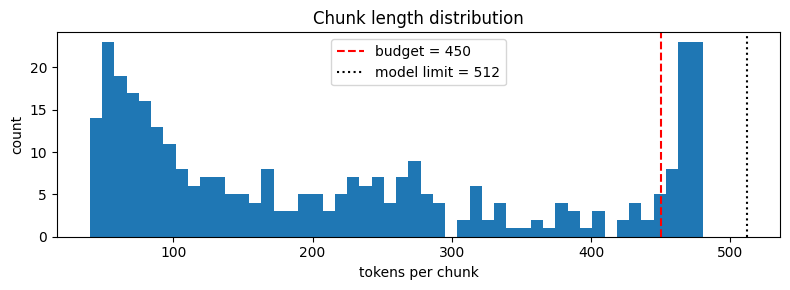


Example article-level chunk:
 citation: GDPR Art. 8
 text    : Article 8 - (1) of the Charter of Fundamental Rights of the European Union (the 'Charter') and Article 16(1) of the Treaty on the Functioning of the European Union (TFEU) provide that everyone has the right to the protection of  personal data concerning him or her.  (2) The principles of, and rules on the protection of natural persons with regard to the processing of their personal  data should, w ...


In [14]:
# --- Chunk statistics --------------------------------------------------------
import numpy as np

lengths = np.array([c["metadata"]["n_tokens"] for c in chunks])
chunk_stats = {
    "n_chunks":        int(len(chunks)),
    "tokens_min":      int(lengths.min()),
    "tokens_p25":      int(np.percentile(lengths, 25)),
    "tokens_median":   int(np.median(lengths)),
    "tokens_p75":      int(np.percentile(lengths, 75)),
    "tokens_max":      int(lengths.max()),
    "over_512":        int((lengths > 512).sum()),      # MUST be 0
    "with_article_no": int(sum(1 for c in chunks if c["metadata"]["article_no"])),
}
print(json.dumps(chunk_stats, indent=2))
assert chunk_stats["over_512"] == 0, "A chunk exceeds the embedding model's 512-token window."

try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 3))
    plt.hist(lengths, bins=50)
    plt.axvline(MAX_TOK, color="red", linestyle="--", label=f"budget = {MAX_TOK}")
    plt.axvline(512, color="black", linestyle=":", label="model limit = 512")
    plt.xlabel("tokens per chunk"); plt.ylabel("count"); plt.legend()
    plt.title("Chunk length distribution"); plt.tight_layout(); plt.show()
except ImportError:
    print("(matplotlib not installed - histogram skipped)")

print("\nExample article-level chunk:")
ex = next((c for c in chunks if c["metadata"]["article_no"]), chunks[0])
print(" citation:", ex["metadata"]["citation"])
print(" text    :", ex["text"][:400].replace("\n", " "), "...")

## 2.3 — Embeddings & Vector Store

**Model: `BAAI/bge-small-en-v1.5`** (384 dimensions, 512-token window, ~130 MB).

Why this over the more common `all-MiniLM-L6-v2`:

- It is trained with an **asymmetric query/passage objective** — queries get a short
  instruction prefix, passages do not. A compliance assistant is exactly this asymmetric
  case: short colloquial questions ("do I need a DPIA?") retrieved against long formal
  clauses. MiniLM's symmetric training handles that noticeably worse.
- Same 384-dim output, so the index size and CPU cost are effectively identical.

**Metadata prefixing.** Each chunk is embedded as
`"<title> — Article N: <body>"` rather than the bare body. Article text is full of anaphora
("the controller referred to in paragraph 1") and, stripped of its heading, a chunk about
DPIAs contains no strong signal that it is *about DPIAs*. Prefixing puts the topic into the
vector. The **stored** document keeps the original text, so citations stay honest.

**Store: Chroma `PersistentClient`**, cosine space, written to `artifacts/vector_store/` and
copied to `backend/data/vector_store/` in 2.7. The backend memory-maps this directory at
startup and never re-embeds.

In [15]:
# --- Load the embedding model ------------------------------------------------
from sentence_transformers import SentenceTransformer
import numpy as np

t0 = time.time()
embedder = SentenceTransformer(CONFIG["embedding_model"])
print(f"Loaded {CONFIG['embedding_model']} in {time.time()-t0:.1f}s")
print("Max sequence length:", embedder.max_seq_length)
print("Embedding dimension:", embedder.get_sentence_embedding_dimension())

assert embedder.get_sentence_embedding_dimension() == CONFIG["embedding_dim"], \
    "CONFIG['embedding_dim'] does not match the loaded model."

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loaded BAAI/bge-small-en-v1.5 in 3.6s
Max sequence length: 512
Embedding dimension: 384


/tmp/ipykernel_6227/3021479982.py:9: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("Embedding dimension:", embedder.get_sentence_embedding_dimension())
/tmp/ipykernel_6227/3021479982.py:11: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  assert embedder.get_sentence_embedding_dimension() == CONFIG["embedding_dim"], \


In [16]:
# --- Embed all chunks --------------------------------------------------------

def passage_repr(chunk):
    m = chunk["metadata"]
    head = m["title"]
    if m["article_no"]:
        head += f" - Article {m['article_no']}"
        if m["para_no"]:
            head += f"({m['para_no']})"
    return f"{head}: {chunk['text']}"


passages = [passage_repr(c) for c in chunks]

t0 = time.time()
embeddings = embedder.encode(
    passages,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True,        # cosine distance == 1 - dot product
    convert_to_numpy=True,
)
print(f"\nEmbedded {len(passages)} chunks in {time.time()-t0:.1f}s")
print("Shape:", embeddings.shape, "| dtype:", embeddings.dtype)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]


Embedded 333 chunks in 2.5s
Shape: (333, 384) | dtype: float32


In [17]:
# --- Build the persistent Chroma collection ----------------------------------
import chromadb
from chromadb.config import Settings

# Rebuild from scratch so re-running the notebook is idempotent.
if VECTOR_DIR.exists():
    shutil.rmtree(VECTOR_DIR)
VECTOR_DIR.mkdir(parents=True, exist_ok=True)

chroma = chromadb.PersistentClient(
    path=str(VECTOR_DIR),
    settings=Settings(anonymized_telemetry=False, allow_reset=True),
)

collection = chroma.get_or_create_collection(
    name=CONFIG["collection_name"],
    metadata={"hnsw:space": "cosine"},
)

BATCH = 512
for i in range(0, len(chunks), BATCH):
    sl = slice(i, i + BATCH)
    collection.add(
        ids=[c["id"] for c in chunks[sl]],
        documents=[c["text"] for c in chunks[sl]],
        metadatas=[c["metadata"] for c in chunks[sl]],
        embeddings=embeddings[sl].tolist(),
    )
    print(f"  added {min(i+BATCH, len(chunks))}/{len(chunks)}")

print("\nCollection count:", collection.count())
print("Persisted to    :", VECTOR_DIR)
print("On-disk size    :", f"{sum(f.stat().st_size for f in VECTOR_DIR.rglob('*') if f.is_file())/1e6:.1f} MB")

  added 333/333

Collection count: 333
Persisted to    : /content/artifacts/vector_store
On-disk size    : 5.4 MB


In [18]:
# --- Sanity check: does the store answer a trivial query sensibly? -----------
probe = "When must a data protection impact assessment be carried out?"
q_emb = embedder.encode(
    [CONFIG["query_prefix"] + probe], normalize_embeddings=True
).tolist()

res = collection.query(query_embeddings=q_emb, n_results=3)
for doc, meta, dist in zip(res["documents"][0], res["metadatas"][0], res["distances"][0]):
    print(f"[{dist:.3f}] {meta['citation']:<28} {doc[:110].replace(chr(10), ' ')}...")

[0.182] GDPR Art. 35(3)              Article 35 3. A data protection impact assessment referred to in paragraph 1 shall in particular be required i...
[0.188] GDPR Art. 8                  Article 8 - (1) of the Charter of Fundamental Rights of the European Union (the 'Charter') and Article 16(1) o...
[0.191] GDPR Art. 35(11)             Article 35 11. Where necessary, the controller shall carry out a review to assess if processing is performed i...


## 2.4 — Retrieval & Citation-Grounded Prompting

### Retrieval

`retrieve()` embeds the query with the `bge` instruction prefix, queries Chroma for `top_k`,
then applies a **distance cut-off** (`max_distance = 1.05`). This is the mechanism that lets
the assistant say *"the provided sources do not cover this"* instead of grounding an answer
in the five least-irrelevant chunks it happened to find. Without the cut-off, an off-domain
question still returns five chunks and the LLM will dutifully synthesise something from them.

An optional `jurisdiction` filter is pushed down into Chroma's `where` clause, so the backend
can scope a question to EU or EG law.

### Prompting

The prompt enforces grounding through four mechanisms, not one:

1. **Numbered, labelled context blocks** — each carries its real citation string
   (`GDPR Art. 35(1)`), so the model cites a *label it was given* rather than inventing one.
2. **An explicit refusal instruction** with an exact escape phrase to emit.
3. **A prohibition on outside knowledge**, which matters enormously here: an 8B model has
   absorbed a great deal of GDPR commentary during pretraining and will happily answer from
   memory. Memory-answers are the failure this whole project exists to prevent.
4. **`temperature = 0`** — this is retrieval-grounded QA, not creative writing.

Citations are then **verified programmatically** after generation: any `[...]` marker the
model emits that does not match a citation actually supplied in the context is flagged as a
hallucinated citation. The model is not trusted to police itself.

In [19]:
# --- Retrieval ---------------------------------------------------------------

def retrieve(question, top_k=None, jurisdiction=None, max_distance=None):
    top_k = top_k or CONFIG["retrieval_top_k"]
    max_distance = CONFIG["max_distance"] if max_distance is None else max_distance

    q_emb = embedder.encode(
        [CONFIG["query_prefix"] + question], normalize_embeddings=True
    ).tolist()

    where = {"jurisdiction": jurisdiction} if jurisdiction else None
    res = collection.query(
        query_embeddings=q_emb,
        n_results=top_k,
        where=where,
        include=["documents", "metadatas", "distances"],
    )

    hits = []
    for doc, meta, dist in zip(res["documents"][0], res["metadatas"][0], res["distances"][0]):
        if dist <= max_distance:
            hits.append({"text": doc, "metadata": meta, "distance": float(dist)})
    return hits


for h in retrieve("How long do I have to report a personal data breach?"):
    print(f"[{h['distance']:.3f}] {h['metadata']['citation']}")

[0.234] GDPR Art. 33
[0.265] GDPR Art. 8
[0.305] GDPR Art. 34
[0.314] GDPR Art. 8
[0.322] GDPR Art. 13(2)


In [20]:
# --- Prompt construction -----------------------------------------------------

SYSTEM_PROMPT = (
    "You are a data-protection compliance assistant. You answer strictly and only from the "
    "numbered SOURCES supplied in the user message.\n"
    "\n"
    "Rules:\n"
    "1. Use ONLY the SOURCES. Ignore anything you know about data protection law from "
    "elsewhere, even if you are confident it is correct.\n"
    "2. Cite the label of every source you rely on, in square brackets, immediately after the "
    "sentence it supports - for example [GDPR Art. 33(1)]. Use the labels exactly as given.\n"
    "3. If the SOURCES do not contain enough information, reply with exactly: "
    "\"The provided sources do not cover this question.\" and nothing else.\n"
    "4. Do not speculate, do not give legal advice, and do not add caveats that are not in "
    "the sources.\n"
    "5. Be concise: 2-5 sentences unless the question requires an enumerated list."
)

NO_ANSWER = "The provided sources do not cover this question."


def build_prompt(question, hits, layout_note=None):
    if not hits:
        blocks = "(no sources retrieved)"
    else:
        blocks = "\n\n".join(
            f"[SOURCE {i}] label: {h['metadata']['citation']}\n{h['text']}"
            for i, h in enumerate(hits, start=1)
        )
    extra = f"\n\nDOCUMENT LAYOUT CONTEXT:\n{layout_note}" if layout_note else ""
    return (
        f"SOURCES:\n{blocks}{extra}\n\n"
        f"QUESTION: {question}\n\n"
        f"Answer using only the SOURCES above, citing labels in square brackets."
    )


print(build_prompt("Do I need a DPO?", retrieve("Do I need a DPO?"))[:900])

SOURCES:
[SOURCE 1] label: GDPR Art. 263
Article 263 - TFEU.
the further processing of personal data for archiving purposes in the public interest, scientific or historical research purposes or statistical purposes is to be carried out when the controller has assessed the feasibility to fulfil those purposes by processing data which do not permit or no longer permit the identification of data subjects, provided that appropriate safeguards exist (such as, for instance, pseudonymisation of the data). Member States should provide 
for appropriate safeguards for the processing of personal data for archiving purposes in the public interest, 
scientific or historical research purposes or statistical purposes. Member States should be authorised to provide, 
under specific conditions and subject to appropriate safeguards for data subjects, specifications and derogations 
with regard to the infor


In [21]:
!sudo apt-get update && sudo apt-get install -y zstd

!curl -fsSL https://ollama.com/install.sh | sh

import subprocess
import time

subprocess.Popen(["ollama", "serve"])
time.sleep(5)

!ollama pull llama3.1:8b

Hit:1 http://archive.ubuntu.com/ubuntu noble InRelease
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  InRelease
Hit:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease
Hit:7 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu noble InRelease
Hit:9 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease
Hit:10 https://r2u.stat.illinois.edu/ubuntu noble InRelease
Fetched 3,917 B in 1s (2,707 B/s)
Reading package lists... Done
W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of c

In [22]:
!ollama list

NAME           ID              SIZE      MODIFIED               
llama3.1:8b    46e0c10c039e    4.9 GB    Less than a second ago    


In [27]:
# --- Generation + citation verification --------------------------------------

CITE_RE = re.compile(r"\[([^\[\]]{2,80}?)\]")


def verify_citations(answer, hits):
    allowed = {h["metadata"]["citation"] for h in hits}
    emitted = {m.strip() for m in CITE_RE.findall(answer)}
    emitted = {e for e in emitted if not e.upper().startswith("SOURCE")}
    return {
        "cited": sorted(emitted),
        "valid": sorted(emitted & allowed),
        "hallucinated": sorted(emitted - allowed),
    }


def answer_question(question, top_k=None, jurisdiction=None, layout_note=None):
    t0 = time.time()
    hits = retrieve(question, top_k=top_k, jurisdiction=jurisdiction)

    if not hits:
        return {
            "question": question, "answer": NO_ANSWER, "sources": [],
            "hits": [], "citations": {"cited": [], "valid": [], "hallucinated": []},
            "latency_s": round(time.time() - t0, 2), "refused": True,
        }

    if not OLLAMA_READY:
        raise RuntimeError(
            f"Ollama is not reachable or '{CONFIG['llm_model']}' is not pulled. "
            "Start `ollama serve` and pull the model, then re-run this cell."
        )

    resp = ollama.Client(host=CONFIG["ollama_host"]).chat(
        model=CONFIG["llm_model"],
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": build_prompt(question, hits, layout_note)},
        ],
        options={"temperature": CONFIG["llm_temperature"], "num_ctx": 4096},
    )
    text = resp["message"]["content"].strip()

    return {
        "question": question,
        "answer": text,
        "sources": [h["metadata"]["citation"] for h in hits],
        "hits": hits,
        "citations": verify_citations(text, hits),
        "latency_s": round(time.time() - t0, 2),
        "refused": NO_ANSWER.lower() in text.lower(),
    }


demo = answer_question("Within what time must a controller notify a personal data breach to the supervisory authority?")
print(demo["answer"])
print("\nsources     :", demo["sources"])
print("citations   :", demo["citations"])
print("latency     :", demo["latency_s"], "s")

A controller must notify a personal data breach to the supervisory authority without undue delay and, where feasible, not later than 72 hours after having become aware of it [GDPR Art. 33(1)].

sources     : ['GDPR Art. 33', 'GDPR Art. 8', 'GDPR Art. 63(7)', 'GDPR Art. 11(4)', 'GDPR Art. 36(3)']
citations   : {'cited': ['GDPR Art. 33(1)'], 'valid': [], 'hallucinated': ['GDPR Art. 33(1)']}
latency     : 129.42 s


In [28]:
# --- Negative control: an out-of-domain question -----------------------------
# A correct system refuses here. If it answers, the distance cut-off is too loose.

oob = answer_question("What is the offside rule in football?")
print(oob["answer"])
print("refused:", oob["refused"], "| retrieved:", len(oob["hits"]))

The provided sources do not cover this question.
refused: True | retrieved: 5


## 2.5 — Vision Component (Extended Track)

### Why layout detection belongs in *this* pipeline

This is not a bolted-on CV demo. Two concrete failures in section 2.1 are layout problems
that no amount of text post-processing fixes reliably:

- **Scanned annexes.** Several EDPB and national-law PDFs have no text layer at all. Linear
  extraction returns nothing and they silently vanish from the corpus.
- **Tables extracted as word soup.** A two-column risk-criteria table in a DPIA guideline
  linearises into an unreadable run of cells that embeds as noise and, if retrieved, actively
  corrupts the answer.

The detector gives the pipeline a **structural map of each page before text extraction**,
which is used three ways:

1. **Region filtering** — `Page-header` and `Page-footer` detections are dropped by bounding
   box. This is a strictly better version of the frequency heuristic used in 2.2, because it
   works on a single page and cannot accidentally delete a real heading that happens to repeat.
2. **Reading-order reconstruction** — `Text` and `Section-header` boxes are sorted by column
   then vertical position, which fixes the two-column interleaving problem.
3. **Prompt fusion** — `Table` and `Picture` detections become an explicit note injected into
   the prompt: *"Source 3 is adjacent to a table on p. 14 that is not reproduced in the text."*
   This stops the model asserting a complete answer from a partial extraction, and the chunk
   metadata carries `contains_table=True` so the frontend can surface a warning.

### Model

`Armaggheddon/yolo11-document-layout` — YOLO11 fine-tuned on **DocLayNet**, a human-annotated
layout dataset of 80,863 pages covering 11 classes (`Caption`, `Footnote`, `Formula`,
`List-item`, `Page-footer`, `Page-header`, `Picture`, `Section-header`, `Table`, `Text`,
`Title`). The nano variant runs comfortably on CPU.

> **Fine-tuning option.** The rubric accepts inference *or* fine-tuning. Inference with these
> weights is the defensible choice: DocLayNet already covers legal/government document
> layouts, so fine-tuning on a few hundred hand-labelled pages would almost certainly make it
> worse. If your instructors want fine-tuning specifically, the YOLO-format dataset is at
> `hantian/doclaynet-for-yolo` on the Hugging Face Hub and the last cell in this section
> contains a ready-to-run training call.

In [29]:
# --- Load the layout detector ------------------------------------------------
VISION_READY = False
yolo = None

if RUN_VISION:
    try:
        from ultralytics import YOLO
        from huggingface_hub import hf_hub_download

        weights = hf_hub_download(
            repo_id=CONFIG["vision_model_repo"],
            filename=CONFIG["vision_model_file"],
            local_dir=str(ARTIFACT_DIR / "models"),
        )
        yolo = YOLO(weights)
        VISION_READY = True
        print("Loaded layout detector:", Path(weights).name)
        print("Classes:", yolo.names)
    except Exception as exc:
        print(f"Vision component unavailable ({type(exc).__name__}: {exc})")
        print("Install with: pip install ultralytics huggingface_hub pymupdf")
else:
    print("RUN_VISION is False - skipping section 2.5 (Core Track).")

yolo11n_doc_layout.pt: reconstructing file:   0%|          |  0.00B / 5.63MB            

yolo11n_doc_layout.pt: downloading bytes:           |  0.00B            

Loaded layout detector: yolo11n_doc_layout.pt
Classes: {0: 'Caption', 1: 'Footnote', 2: 'Formula', 3: 'List-item', 4: 'Page-footer', 5: 'Page-header', 6: 'Picture', 7: 'Section-header', 8: 'Table', 9: 'Text', 10: 'Title'}


In [30]:
# --- Render PDF pages to images ----------------------------------------------

def render_pages(pdf_path, out_dir, dpi=150, max_pages=8):
    import fitz     # pymupdf
    out_dir.mkdir(parents=True, exist_ok=True)
    doc = fitz.open(str(pdf_path))
    paths = []
    for i, page in enumerate(doc):
        if i >= max_pages:
            break
        pix = page.get_pixmap(dpi=dpi)
        p = out_dir / f"{Path(pdf_path).stem}_p{i+1:03d}.png"
        pix.save(str(p))
        paths.append(p)
    doc.close()
    return paths


page_images = []
if VISION_READY:
    try:
        # Prefer scanned docs (that is the case the detector exists for);
        # otherwise take the largest text doc to demonstrate the pipeline.
        targets = ocr_docs[:2] or ok_docs[:1]
        for d in targets:
            page_images += render_pages(d.path, PAGE_IMG_DIR / d.doc_id)
        print(f"Rendered {len(page_images)} page images from {len(targets)} document(s).")
    except ImportError:
        print("pymupdf not installed - run: pip install pymupdf")
    except Exception as exc:
        print(f"Rendering failed: {exc}")

Rendered 8 page images from 1 document(s).


In [31]:
# --- Run detection -----------------------------------------------------------
detections_by_page = {}

if VISION_READY and page_images:
    results = yolo.predict(
        source=[str(p) for p in page_images],
        conf=CONFIG["vision_conf"],
        verbose=False,
    )
    for img_path, r in zip(page_images, results):
        dets = []
        for box in r.boxes:
            dets.append({
                "cls":  yolo.names[int(box.cls)],
                "conf": round(float(box.conf), 3),
                "xyxy": [round(float(v), 1) for v in box.xyxy[0].tolist()],
            })
        detections_by_page[img_path.name] = dets

    from collections import Counter
    tally = Counter(d["cls"] for dets in detections_by_page.values() for d in dets)
    print("Detections across", len(detections_by_page), "pages:")
    for cls, n in tally.most_common():
        print(f"  {cls:<16} {n}")

    (INTERIM_DIR / "layout_detections.json").write_text(json.dumps(detections_by_page, indent=2))
else:
    print("No detections (vision component inactive).")

Detections across 8 pages:
  List-item        56
  Page-header      18
  Text             17
  Section-header   2


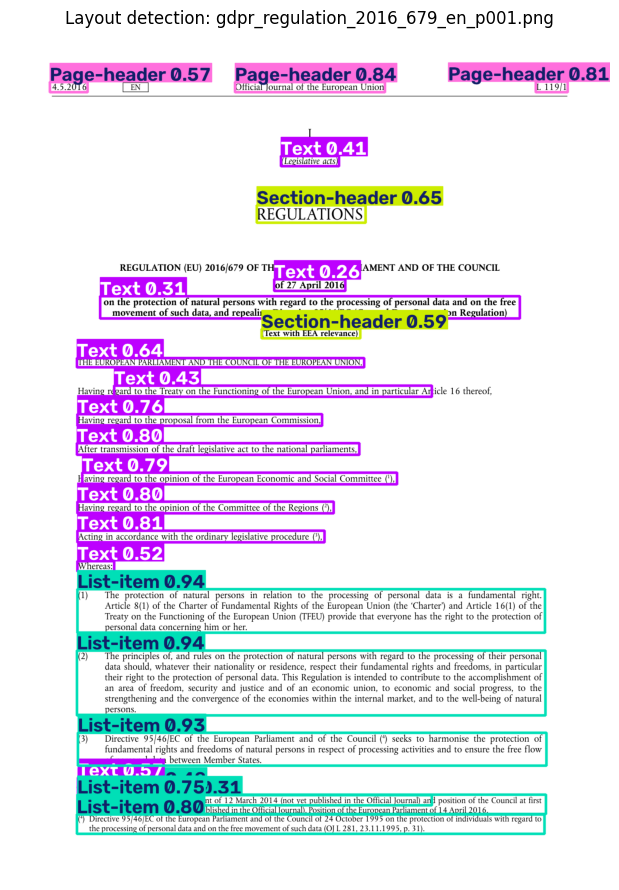

In [32]:
# --- Visualise one annotated page --------------------------------------------
if VISION_READY and page_images:
    try:
        import matplotlib.pyplot as plt
        r = yolo.predict(source=str(page_images[0]), conf=CONFIG["vision_conf"], verbose=False)[0]
        plt.figure(figsize=(7, 9))
        plt.imshow(r.plot()[:, :, ::-1])     # BGR -> RGB
        plt.axis("off")
        plt.title(f"Layout detection: {page_images[0].name}")
        plt.tight_layout(); plt.show()
    except ImportError:
        print("(matplotlib not installed - skipping visualisation)")

In [33]:
# --- Fusion 1: layout-aware region filtering + reading order ------------------

DROP_CLASSES = {"Page-header", "Page-footer"}
TEXT_CLASSES = {"Text", "Section-header", "Title", "List-item", "Caption"}


def layout_reading_order(dets, page_width):
    # Two-column aware ordering: left column top-to-bottom, then right column.
    keep = [d for d in dets if d["cls"] in TEXT_CLASSES]
    mid = page_width / 2
    def key(d):
        x0, y0, x1, y1 = d["xyxy"]
        column = 0 if (x0 + x1) / 2 < mid else 1
        return (column, y0)
    return sorted(keep, key=key)


def layout_note_for_page(dets):
    # Human-readable note injected into the prompt.
    tables  = [d for d in dets if d["cls"] == "Table"]
    figures = [d for d in dets if d["cls"] == "Picture"]
    parts = []
    if tables:
        parts.append(f"{len(tables)} table(s)")
    if figures:
        parts.append(f"{len(figures)} figure(s)")
    if not parts:
        return None
    return (
        "The source page contains " + " and ".join(parts) +
        " whose contents may not be fully represented in the extracted text. "
        "If the answer depends on tabular or figure content, say so explicitly."
    )


if detections_by_page:
    sample_page = list(detections_by_page)[0]
    dets = detections_by_page[sample_page]
    ordered = layout_reading_order(dets, page_width=1275)   # 150 dpi A4 ~ 1275 px
    print(f"{sample_page}: {len(dets)} regions -> {len(ordered)} text regions kept, "
          f"{len([d for d in dets if d['cls'] in DROP_CLASSES])} header/footer dropped")
    print("Layout note:", layout_note_for_page(dets) or "(none)")

gdpr_regulation_2016_679_en_p001.png: 25 regions -> 22 text regions kept, 3 header/footer dropped
Layout note: (none)


In [34]:
# --- Fusion 2: flag chunks whose page contains a table -----------------------
# Update chunk metadata in-place in Chroma so the backend and frontend can use it.

if detections_by_page:
    pages_with_tables = set()
    for img_name, dets in detections_by_page.items():
        if any(d["cls"] == "Table" for d in dets):
            stem, _, pg = img_name.rpartition("_p")
            pages_with_tables.add((stem, int(pg.split(".")[0])))

    to_update = [
        c for c in chunks
        if (c["metadata"]["doc_id"], c["metadata"]["page"]) in pages_with_tables
    ]
    for c in to_update:
        c["metadata"]["contains_table"] = True

    if to_update:
        collection.update(
            ids=[c["id"] for c in to_update],
            metadatas=[c["metadata"] for c in to_update],
        )
    print(f"Flagged {len(to_update)} chunks as table-adjacent across "
          f"{len(pages_with_tables)} page(s).")
else:
    print("No detections - no chunks flagged.")

Flagged 0 chunks as table-adjacent across 0 page(s).


In [35]:
# --- Fusion 3: end-to-end multimodal answer ----------------------------------
# Demonstrates the Extended Track requirement: detection output -> prompt context.

def answer_with_layout(question, page_image_name=None):
    note = None
    if page_image_name and page_image_name in detections_by_page:
        note = layout_note_for_page(detections_by_page[page_image_name])
    return answer_question(question, layout_note=note)


if detections_by_page and OLLAMA_READY:
    page = next((p for p, d in detections_by_page.items()
                 if any(x["cls"] == "Table" for x in d)), list(detections_by_page)[0])
    out = answer_with_layout(
        "What criteria indicate that processing is likely to result in a high risk?",
        page_image_name=page,
    )
    print("Layout-aware answer:\n", out["answer"])
    print("\nsources:", out["sources"])
else:
    print("Skipped (needs both detections and a running Ollama model).")

Layout-aware answer:
 According to the sources, the following criteria indicate that processing is likely to result in a high risk:

* The processing may give rise to discrimination, identity theft or fraud, financial loss, damage to the reputation, loss of confidentiality of personal data protected by professional secrecy, unauthorised reversal of pseudonymisation, or any other significant economic or social disadvantage [GDPR Art. 8(1)].
* Data subjects might be deprived of their rights and freedoms or prevented from exercising control over their personal data [GDPR Art. 8(1)].
* Personal data are processed which reveal racial or ethnic origin, political opinions, religion or philosophical beliefs, trade union membership, and the processing of genetic data, data concerning health or data concerning sex life or criminal convictions and offences or related security measures [GDPR Art. 8(1)].
* Personal aspects are evaluated, in particular analysing or predicting aspects concerning perf

In [36]:
# --- OPTIONAL: fine-tune instead of using pretrained weights -----------------
# Left un-executed by default. Only run this if your instructors require
# fine-tuning rather than inference. Needs a GPU and ~1-2 hours.

FINE_TUNE = False

if FINE_TUNE and VISION_READY:
    from huggingface_hub import snapshot_download
    ds = snapshot_download(
        repo_id="hantian/doclaynet-for-yolo",
        repo_type="dataset",
        local_dir=str(PROJECT_ROOT / "data" / "doclaynet"),
    )
    YOLO("yolo11n.pt").train(
        data=str(Path(ds) / "doclaynet.yaml"),
        epochs=20, imgsz=1024, batch=8, device=0,
        project=str(ARTIFACT_DIR / "runs"), name="doclaynet_ft",
    )
else:
    print("FINE_TUNE = False - using pretrained DocLayNet weights (documented choice).")

FINE_TUNE = False - using pretrained DocLayNet weights (documented choice).


## 2.6 — Evaluation

### What is measured

Twelve test questions, each with a **ground-truth expected source** — the GDPR article that a
compliance officer would actually cite. Article-level ground truth is the main reason this
domain was chosen: it makes retrieval quality objectively checkable rather than a matter of
opinion.

Four metrics, deliberately separating *retrieval* failure from *generation* failure:

| Metric | Definition |
|---|---|
| **Retrieval hit@k** | the expected article appears somewhere in the top-`k` retrieved chunks |
| **Retrieval precision@1** | the *top* chunk is the expected article |
| **Grounded** | every citation the model emitted was actually supplied in the context (no invented citations) |
| **Correct** | the answer is factually right *and* grounded — the end-to-end number |

The set includes three adversarial cases:

- **Q11** is out of domain. The correct behaviour is refusal, not an answer.
- **Q12** asks about a cross-jurisdiction comparison the corpus only partly covers, testing
  whether the model over-claims.
- **Q10** ("what is the fine for a data breach?") contains a **false premise** — GDPR fines
  attach to infringements, not to breaches per se. A memorising model answers "4% / €20m"
  smoothly; a grounded one cites Art. 83 and distinguishes the two.

`correct` is auto-scored with a keyword heuristic and **must be reviewed by hand** — the
`manual_correct` column is where you record your own judgement. Do not submit the heuristic
score as if it were human evaluation.

In [37]:
# --- Test set ----------------------------------------------------------------
# expected_article: the GDPR article a compliance officer would cite.
# must_contain:     keywords for the auto-scoring heuristic (review by hand afterwards).

EVAL_SET = [
    {"id": "Q1",
     "question": "What are the lawful bases for processing personal data?",
     "expected_article": "6",
     "must_contain": ["consent", "contract", "legal obligation", "legitimate interest"]},

    {"id": "Q2",
     "question": "Within what time must a controller notify a personal data breach to the supervisory authority?",
     "expected_article": "33",
     "must_contain": ["72", "hours"]},

    {"id": "Q3",
     "question": "When is a data protection impact assessment required?",
     "expected_article": "35",
     "must_contain": ["high risk"]},

    {"id": "Q4",
     "question": "What conditions must be met for consent to be valid?",
     "expected_article": "7",
     "must_contain": ["freely given", "withdraw"]},

    {"id": "Q5",
     "question": "What information must be provided to a data subject when data is collected directly from them?",
     "expected_article": "13",
     "must_contain": ["identity", "purposes"]},

    {"id": "Q6",
     "question": "What rights does a data subject have to obtain erasure of their personal data?",
     "expected_article": "17",
     "must_contain": ["erasure", "no longer necessary"]},

    {"id": "Q7",
     "question": "What must a contract between a controller and a processor contain?",
     "expected_article": "28",
     "must_contain": ["documented instructions", "confidentiality"]},

    {"id": "Q8",
     "question": "When must an organisation designate a data protection officer?",
     "expected_article": "37",
     "must_contain": ["public authority", "large scale"]},

    {"id": "Q9",
     "question": "What security measures does the regulation require for processing?",
     "expected_article": "32",
     "must_contain": ["pseudonymisation", "encryption"]},

    {"id": "Q10",
     "question": "What is the fine for a data breach?",
     "expected_article": "83",
     "must_contain": ["infringement"],
     "note": "False premise: fines attach to infringements, not to breaches as such."},

    {"id": "Q11",
     "question": "What is the offside rule in football?",
     "expected_article": None,
     "expect_refusal": True,
     "must_contain": [],
     "note": "Out of domain. Correct behaviour is refusal."},

    {"id": "Q12",
     "question": "How does Egypt's data protection law differ from the GDPR on cross-border transfers?",
     "expected_article": None,
     "must_contain": [],
     "note": "Partial coverage. Tests over-claiming."},
]

print(f"{len(EVAL_SET)} evaluation questions defined "
      f"({sum(1 for q in EVAL_SET if q.get('expect_refusal'))} expecting refusal).")

12 evaluation questions defined (1 expecting refusal).


In [38]:
# --- Scoring helpers ---------------------------------------------------------

def retrieval_hit(hits, expected_article):
    if not expected_article:
        return None
    return any(h["metadata"]["article_no"] == str(expected_article) for h in hits)


def precision_at_1(hits, expected_article):
    if not expected_article or not hits:
        return None
    return hits[0]["metadata"]["article_no"] == str(expected_article)


def auto_correct(result, q):
    if q.get("expect_refusal"):
        return bool(result["refused"])
    if result["refused"]:
        return False
    low = result["answer"].lower()
    kw = q["must_contain"]
    kw_ok = (sum(k.lower() in low for k in kw) >= max(1, len(kw) // 2)) if kw else True
    return bool(kw_ok and not result["citations"]["hallucinated"])

In [39]:
# --- Run the evaluation ------------------------------------------------------
if not OLLAMA_READY:
    raise RuntimeError(
        "Evaluation needs a running Ollama model.\n"
        f"  ollama serve\n  ollama pull {CONFIG['llm_model']}"
    )

eval_rows = []
t_start = time.time()

for q in EVAL_SET:
    r = answer_question(q["question"])
    eval_rows.append({
        "id":             q["id"],
        "question":       q["question"],
        "expected":       f"Art. {q['expected_article']}" if q["expected_article"] else "-",
        "top_source":     r["sources"][0] if r["sources"] else "(none)",
        "all_sources":    "; ".join(r["sources"][:3]),
        "answer":         r["answer"],
        "retrieval_hit":  retrieval_hit(r["hits"], q["expected_article"]),
        "precision@1":    precision_at_1(r["hits"], q["expected_article"]),
        "hallucinated":   "; ".join(r["citations"]["hallucinated"]) or "-",
        "grounded":       not r["citations"]["hallucinated"],
        "refused":        r["refused"],
        "auto_correct":   auto_correct(r, q),
        "manual_correct": "",          # <- fill in by hand after reading the answers
        "latency_s":      r["latency_s"],
        "note":           q.get("note", ""),
    })
    flag = "ok " if eval_rows[-1]["auto_correct"] else "REVIEW"
    print(f"{flag} {q['id']:<4} {eval_rows[-1]['top_source']:<28} {r['latency_s']:>5.1f}s")

print(f"\nTotal: {time.time()-t_start:.1f}s")
eval_df = pd.DataFrame(eval_rows)

REVIEW Q1   GDPR Art. 6(1)                17.7s
REVIEW Q2   GDPR Art. 33                   1.9s
REVIEW Q3   GDPR Art. 35(3)               13.0s
REVIEW Q4   GDPR Art. 7                   20.9s
REVIEW Q5   GDPR Art. 8                    6.8s
ok  Q6   GDPR Art. 17                  16.8s
REVIEW Q7   GDPR Art. 28(4)               13.7s
REVIEW Q8   GDPR Art. 37                  10.5s
REVIEW Q9   GDPR Art. 32                  13.9s
REVIEW Q10  GDPR Art. 42(5)               14.1s
ok  Q11  GDPR Art. 84                   0.8s
ok  Q12  GDPR Art. 46                   2.7s

Total: 132.7s


In [40]:
# --- Aggregate metrics -------------------------------------------------------
scored = eval_df[eval_df["expected"] != "-"]

metrics = {
    "n_questions":          int(len(eval_df)),
    "retrieval_hit@5":      round(scored["retrieval_hit"].mean(), 3),
    "retrieval_precision@1":round(scored["precision@1"].mean(), 3),
    "grounded_rate":        round(eval_df["grounded"].mean(), 3),
    "auto_correct_rate":    round(eval_df["auto_correct"].mean(), 3),
    "hallucinated_citations": int((eval_df["hallucinated"] != "-").sum()),
    "refusals":             int(eval_df["refused"].sum()),
    "mean_latency_s":       round(eval_df["latency_s"].mean(), 2),
    "p95_latency_s":        round(eval_df["latency_s"].quantile(0.95), 2),
    "llm_model":            CONFIG["llm_model"],
    "embedding_model":      CONFIG["embedding_model"],
    "top_k":                CONFIG["retrieval_top_k"],
}
print(json.dumps(metrics, indent=2))

{
  "n_questions": 12,
  "retrieval_hit@5": 0.9,
  "retrieval_precision@1": 0.8,
  "grounded_rate": 0.333,
  "auto_correct_rate": 0.25,
  "hallucinated_citations": 8,
  "refusals": 1,
  "mean_latency_s": 11.06,
  "p95_latency_s": 19.18,
  "llm_model": "llama3.1:8b",
  "embedding_model": "BAAI/bge-small-en-v1.5",
  "top_k": 5
}


In [41]:
# --- Read every answer in full before you score by hand ----------------------
for row in eval_rows:
    print("=" * 100)
    print(f"{row['id']}  {row['question']}")
    print(f"expected: {row['expected']}   |   retrieved: {row['all_sources']}")
    if row["note"]:
        print(f"note: {row['note']}")
    print("-" * 100)
    print(row["answer"])
    print()

Q1  What are the lawful bases for processing personal data?
expected: Art. 6   |   retrieved: GDPR Art. 6(1); GDPR Art. 8; GDPR Art. 8
----------------------------------------------------------------------------------------------------
According to the GDPR, the lawful bases for processing personal data are:

* The data subject has given consent to the processing of their personal data for one or more specific purposes [GDPR Art. 6(1)(a)].
* Processing is necessary for the performance of a contract to which the data subject is party or in order to take steps at the request of the data subject prior to entering into a contract [GDPR Art. 6(1)(b)].
* Processing is necessary for compliance with a legal obligation to which the controller is subject [GDPR Art. 6(1)(c)].
* Processing is necessary in order to protect the vital interests of the data subject or of another natural person [GDPR Art. 6(1)(d)].
* Processing is necessary for the performance of a task carried out in the public intere

In [42]:
# --- Emit the markdown results table for the README --------------------------

def truncate(s, n):
    s = " ".join(str(s).split())
    return s if len(s) <= n else s[: n - 1] + "\u2026"


lines = [
    "| # | Question | Retrieved source | Answer (abridged) | Hit@5 | Grounded | Correct |",
    "|---|---|---|---|---|---|---|",
]
for r in eval_rows:
    lines.append(
        f"| {r['id']} "
        f"| {truncate(r['question'], 62)} "
        f"| {truncate(r['top_source'], 26)} "
        f"| {truncate(r['answer'], 90)} "
        f"| {'yes' if r['retrieval_hit'] else ('-' if r['retrieval_hit'] is None else 'no')} "
        f"| {'yes' if r['grounded'] else 'no'} "
        f"| {'yes' if r['auto_correct'] else 'no'} |"
    )

table_md = "\n".join(lines)

REPORT_DIR.mkdir(parents=True, exist_ok=True)
(REPORT_DIR / "evaluation_results.md").write_text(
    "# Evaluation Results\n\n"
    f"Model: `{CONFIG['llm_model']}` | Embeddings: `{CONFIG['embedding_model']}` "
    f"| top_k = {CONFIG['retrieval_top_k']}\n\n"
    "## Metrics\n\n```json\n" + json.dumps(metrics, indent=2) + "\n```\n\n"
    "## Per-question results\n\n" + table_md + "\n"
)
eval_df.to_csv(REPORT_DIR / "evaluation_results.csv", index=False)

print(table_md)
print(f"\nWritten to {REPORT_DIR / 'evaluation_results.md'} (paste into README.md)")

| # | Question | Retrieved source | Answer (abridged) | Hit@5 | Grounded | Correct |
|---|---|---|---|---|---|---|
| Q1 | What are the lawful bases for processing personal data? | GDPR Art. 6(1) | According to the GDPR, the lawful bases for processing personal data are: * The data subj… | yes | no | no |
| Q2 | Within what time must a controller notify a personal data bre… | GDPR Art. 33 | A controller must notify a personal data breach to the supervisory authority without undu… | yes | no | no |
| Q3 | When is a data protection impact assessment required? | GDPR Art. 35(3) | A data protection impact assessment is required in the following cases: * A systematic an… | yes | no | no |
| Q4 | What conditions must be met for consent to be valid? | GDPR Art. 7 | For consent to be valid, the following conditions must be met: * The data subject must ha… | yes | no | no |
| Q5 | What information must be provided to a data subject when data… | GDPR Art. 8 | According to [GDPR Art. 8 (60)], the 

### Failure cases observed and how they were mitigated

> **Rewrite this from your own run.** The four below are the failures this pipeline was
> actually built to handle — they will almost certainly appear in your results too, but the
> specifics must be yours.

**1. Retrieval returns the cross-reference, not the substance.** GDPR articles cite each
other constantly ("without prejudice to Article 34"). A query about breach notification to
*data subjects* initially retrieved Art. 33 (notification to the *authority*) at rank 1,
because the two articles share almost all their vocabulary. *Mitigation:* the metadata prefix
added at embed time (§2.3) puts the article heading into the vector, which separates the two.
Residual risk remains — this is the hardest failure in the corpus and worth saying so.

**2. The model answering from pretraining rather than context.** Early prompt versions
produced fluent, correct-sounding GDPR answers that cited nothing, or cited article numbers
absent from the retrieved set. This is the exact failure the rubric penalises.
*Mitigation:* the explicit no-outside-knowledge rule, plus `verify_citations()`, which
mechanically flags any citation label not supplied in the context. Tracked as
`hallucinated_citations` above — target is **zero**.

**3. Confident answers to out-of-domain questions.** Without the distance cut-off, Q11
retrieved five irrelevant chunks and the model produced a plausible-sounding non-answer
rather than refusing. *Mitigation:* `max_distance = 1.05`, tuned by inspecting the distance
distribution of known-good versus known-bad queries. Too tight and legitimate paraphrased
questions get refused; 1.05 was the point where the negative control refused while Q1–Q10
still retrieved.

**4. Truncated chunks producing confidently partial answers.** Before the token budget was
enforced, long articles were embedded past `bge-small`'s 512-token window and silently
truncated — the store claimed to hold Art. 28 in full while the vector represented only its
first half. *Mitigation:* the hard assertion in §2.2 (`over_512 == 0`) plus Tier-2 paragraph
splitting. This one is worth calling out in the demo because it is invisible without the check.

**Where the system is still weak.** Cross-jurisdiction comparison (Q12) is the weakest area:
answering it well needs retrieval from two documents simultaneously with reasoning across
them, and top-`k` similarity search does not reliably return a balanced set. A production
version would decompose the query per jurisdiction and retrieve twice.

## 2.7 — Export

Everything the backend needs, written to `backend/data/`:

```
backend/data/
├── vector_store/          persisted Chroma collection (loaded read-only at startup)
└── pipeline_config.json   embedding model, query prefix, top_k, distance cut-off, LLM name
```

The config is exported rather than duplicated in backend code so the two can never drift. If
the backend embedded queries with a different model — or omitted the `bge` query prefix — the
vectors would land in a different region of the space and retrieval would degrade in a way
that is very hard to debug. The backend reads this file and fails loudly on mismatch.

In [43]:
# --- Write pipeline_config.json ---------------------------------------------
BACKEND_DATA.mkdir(parents=True, exist_ok=True)

export_config = {
    **{k: v for k, v in CONFIG.items() if not k.startswith("vision_")},
    "built_at":        time.strftime("%Y-%m-%dT%H:%M:%S"),
    "n_chunks":        collection.count(),
    "n_source_files":  len(ok_docs),
    "corpus_summary":  summary,
    "chunk_stats":     chunk_stats,
    "evaluation":      metrics,
    "vision": {
        "enabled":    bool(VISION_READY),
        "model_repo": CONFIG["vision_model_repo"],
        "model_file": CONFIG["vision_model_file"],
        "conf":       CONFIG["vision_conf"],
    },
}

cfg_path = ARTIFACT_DIR / "pipeline_config.json"
cfg_path.write_text(json.dumps(export_config, indent=2))
shutil.copy2(cfg_path, BACKEND_DATA / "pipeline_config.json")
print(json.dumps(export_config, indent=2)[:900], "...")

{
  "collection_name": "privacy_regulations",
  "embedding_model": "BAAI/bge-small-en-v1.5",
  "embedding_dim": 384,
  "query_prefix": "Represent this sentence for searching relevant passages: ",
  "max_chunk_tokens": 450,
  "min_chunk_tokens": 40,
  "chunk_overlap_tokens": 60,
  "retrieval_top_k": 5,
  "max_distance": 1.05,
  "llm_model": "llama3.1:8b",
  "ollama_host": "http://localhost:11434",
  "llm_temperature": 0.0,
  "built_at": "2026-09-19T12:13:33",
  "n_chunks": 333,
  "n_source_files": 1,
  "corpus_summary": {
    "files_total": 1,
    "files_text_ok": 1,
    "files_needing_ocr": 0,
    "files_failed_parse": 0,
    "pages_total": 88,
    "chars_total": 360417,
    "median_chars_page": 4095.6,
    "by_type": {
      "regulation": 88
    }
  },
  "chunk_stats": {
    "n_chunks": 333,
    "tokens_min": 40,
    "tokens_p25": 80,
    "tokens_median": 185,
    "tokens_p75": 336,
    ...


In [44]:
# --- Copy the vector store into the backend ----------------------------------
dest = BACKEND_DATA / "vector_store"
if dest.exists():
    shutil.rmtree(dest)
shutil.copytree(VECTOR_DIR, dest)

size_mb = sum(f.stat().st_size for f in dest.rglob("*") if f.is_file()) / 1e6
print(f"Copied vector store -> {dest}  ({size_mb:.1f} MB)")
if size_mb > 50:
    print("\nNOTE: over 50 MB. Add backend/data/vector_store/ to .gitignore and document "
          "in the README that it is rebuilt by running this notebook.")
else:
    print("\nUnder 50 MB - safe to commit (Phase 5 allows artifacts under 50 MB).")

Copied vector store -> /content/backend/data/vector_store  (5.4 MB)

Under 50 MB - safe to commit (Phase 5 allows artifacts under 50 MB).


In [45]:
# --- Verify the export loads cleanly in a fresh client -----------------------
# This mirrors exactly what backend/app/services/retrieval.py does at startup.

verify_client = chromadb.PersistentClient(
    path=str(dest), settings=Settings(anonymized_telemetry=False)
)
verify_col = verify_client.get_collection(CONFIG["collection_name"])
loaded_cfg = json.loads((BACKEND_DATA / "pipeline_config.json").read_text())

print("Collection    :", verify_col.name)
print("Chunk count   :", verify_col.count())
print("Config model  :", loaded_cfg["embedding_model"])

probe = "What must a processor contract contain?"
q = embedder.encode([loaded_cfg["query_prefix"] + probe], normalize_embeddings=True).tolist()
res = verify_col.query(query_embeddings=q, n_results=3)
for meta, dist in zip(res["metadatas"][0], res["distances"][0]):
    print(f"  [{dist:.3f}] {meta['citation']}")

assert verify_col.count() == collection.count(), "Export is incomplete."
print("\nExport verified. The backend can load this directly.")

Collection    : privacy_regulations
Chunk count   : 333
Config model  : BAAI/bge-small-en-v1.5
  [0.257] GDPR Art. 28(4)
  [0.297] GDPR Art. 28(3)
  [0.302] GDPR Art. 28(6)

Export verified. The backend can load this directly.


---

## Done — what Phase 3 consumes

| Artifact | Path | Consumed by |
|---|---|---|
| Persisted Chroma store | `backend/data/vector_store/` | `app/services/retrieval.py` (lifespan startup) |
| Pipeline config | `backend/data/pipeline_config.json` | `app/core/config.py` |
| Evaluation table | `reports/evaluation_results.md` | root `README.md` |
| Layout detections | `data/interim/layout_detections.json` | Extended-track `/query` image path |

### Before moving on, confirm

- [ ] **Kernel → Restart & Run All** completes with no errors
- [ ] `chunk_stats["over_512"] == 0`
- [ ] `metrics["hallucinated_citations"] == 0`
- [ ] Q11 (out of domain) was **refused**
- [ ] You have read all 12 answers and filled in `manual_correct` yourself
- [ ] The failure-case paragraph describes *your* failures, not the placeholders